<a href="https://colab.research.google.com/github/louisnguyen-eep/AgenticAIforBusiness118S/blob/dev/SupplyChainAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# Inventory Replenishment Agent
# ============================================================

!pip install anthropic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.5/627.5 kB 26.8 MB/s eta 0:00:00


In [4]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from collections import defaultdict
import textwrap, io

In [5]:
# 2. ── Generate synthetic data ──────────────────────────────────────────────

np.random.seed(42)
START = pd.Timestamp("2024-01-01")
HORIZON = 90  # days

SKUS = {
    "SKU-A": {"mu": 20, "sigma": 4},   # steady seller
    "SKU-B": {"mu": 8,  "sigma": 3},   # slow mover
    "SKU-C": {"mu": 50, "sigma": 10},  # high-velocity
}

dates = pd.date_range(START, periods=HORIZON, freq="D")

rows = []
for sku, props in SKUS.items():
    qty = np.random.normal(props["mu"], props["sigma"], HORIZON).clip(0).round().astype(int)
    for d, q in zip(dates, qty):
        rows.append({"date": d, "sku": sku, "qty_sold": q})

sales_df = pd.DataFrame(rows)

inventory_df = pd.DataFrame([
    {"sku": "SKU-A", "opening_stock": 200},
    {"sku": "SKU-B", "opening_stock": 80},
    {"sku": "SKU-C", "opening_stock": 500},
])

params_df = pd.DataFrame([
    {"sku": "SKU-A", "unit_cost": 10.0, "holding_cost_per_day": 0.05,
     "stockout_cost": 25.0, "lead_time_days": 5, "min_order_qty": 50,  "service_level": 0.95},
    {"sku": "SKU-B", "unit_cost": 30.0, "holding_cost_per_day": 0.10,
     "stockout_cost": 75.0, "lead_time_days": 7, "min_order_qty": 20,  "service_level": 0.97},
    {"sku": "SKU-C", "unit_cost": 5.0,  "holding_cost_per_day": 0.02,
     "stockout_cost": 15.0, "lead_time_days": 3, "min_order_qty": 200, "service_level": 0.90},
])

# Optionally save to CSV (uncomment if you want real files)
# sales_df.to_csv("sales.csv", index=False)
# inventory_df.to_csv("inventory.csv", index=False)
# params_df.to_csv("params.csv", index=False)

print("=== Sales sample ==="); print(sales_df.head(6))
print("\n=== Inventory ===");   print(inventory_df)
print("\n=== Params ===");      print(params_df)


=== Sales sample ===
        date    sku  qty_sold
0 2024-01-01  SKU-A        22
1 2024-01-02  SKU-A        19
2 2024-01-03  SKU-A        23
3 2024-01-04  SKU-A        26
4 2024-01-05  SKU-A        19
5 2024-01-06  SKU-A        19

=== Inventory ===
     sku  opening_stock
0  SKU-A            200
1  SKU-B             80
2  SKU-C            500

=== Params ===
     sku  unit_cost  holding_cost_per_day  stockout_cost  lead_time_days  \
0  SKU-A       10.0                  0.05           25.0               5   
1  SKU-B       30.0                  0.10           75.0               7   
2  SKU-C        5.0                  0.02           15.0               3   

   min_order_qty  service_level  
0             50           0.95  
1             20           0.97  
2            200           0.90  


In [6]:
# 3. ── Load & aggregate demand ─────────────────────────────────────────────

# If loading from CSV instead, replace the three lines above with:
# sales_df     = pd.read_csv("sales.csv",     parse_dates=["date"])
# inventory_df = pd.read_csv("inventory.csv")
# params_df    = pd.read_csv("params.csv")

demand = (
    sales_df
    .groupby(["date", "sku"], as_index=False)["qty_sold"]
    .sum()
    .pivot(index="date", columns="sku", values="qty_sold")
    .fillna(0)
    .astype(float)
)
demand.columns.name = None
print("\n=== Daily demand (first 5 rows) ===")
print(demand.head())


=== Daily demand (first 5 rows) ===
            SKU-A  SKU-B  SKU-C
date                           
2024-01-01   22.0    8.0   56.0
2024-01-02   19.0   11.0   41.0
2024-01-03   23.0    6.0   39.0
2024-01-04   26.0    7.0   55.0
2024-01-05   19.0    7.0   48.0


In [7]:
# 4. ── EWMA Forecaster ──────────────────────────────────────────────────────

def ewma_forecast(series: pd.Series, alpha: float = 0.3) -> pd.Series:
    """
    Returns a one-step-ahead EWMA forecast.
    forecast[t] = alpha * actual[t-1] + (1-alpha) * forecast[t-1]
    First forecast = first observation (warm-start).
    """
    forecasts = [series.iloc[0]]
    for obs in series.iloc[1:]:
        forecasts.append(alpha * obs + (1 - alpha) * forecasts[-1])
    return pd.Series(forecasts, index=series.index)


alpha = 0.3
forecasts = {}      # sku → Series of smoothed demand
forecast_errors = {}  # sku → rolling std of (actual - forecast)

for sku in demand.columns:
    f = ewma_forecast(demand[sku], alpha=alpha)
    err = demand[sku] - f
    forecasts[sku] = f
    forecast_errors[sku] = err.std()  # single scalar; re-computed rolling inside agent

In [8]:
# 5. ── Safety stock calculator ─────────────────────────────────────────────

def safety_stock(sigma_demand: float, lead_time: int, service_level: float) -> float:
    """
    SS = z * sigma_demand * sqrt(lead_time)
    z  = inverse-normal CDF at service_level.
    """
    z = norm.ppf(service_level)
    return z * sigma_demand * np.sqrt(lead_time)


params = params_df.set_index("sku").to_dict("index")

for sku, p in params.items():
    sigma = forecast_errors[sku]
    ss = safety_stock(sigma, p["lead_time_days"], p["service_level"])
    params[sku]["safety_stock"] = ss
    print(f"{sku:6s}  σ={sigma:.2f}  SS={ss:.1f}")


SKU-A   σ=2.82  SS=10.4
SKU-B   σ=2.24  SS=11.2
SKU-C   σ=8.24  SS=18.3


In [11]:
# 6. ── Claude-powered Agent Loop ──────────────────────────────────────────

import anthropic
import json

client = anthropic.Anthropic()  # uses ANTHROPIC_API_KEY env var

# ── Helper: build the prompt for Claude ──────────────────────────────────────

def build_agent_prompt(sku, date, stock, ewma_demand, safety_stock, pending_qty,
                       proj_inventory, reorder_point, params):
    p = params[sku]
    return f"""You are an inventory replenishment agent making a daily purchase order decision.

## Today's situation for {sku} on {date}
- On-hand stock (end of day): {stock:.1f} units
- In-transit stock (pending POs): {pending_qty:.1f} units
- Inventory position (on-hand + in-transit): {stock + pending_qty:.1f} units
- EWMA forecast (daily demand): {ewma_demand:.1f} units/day
- Lead time: {p['lead_time_days']} days
- Review period: 1 day
- Projected inventory at end of risk window (lead time + review): {proj_inventory:.1f} units
- Safety stock required (service level {p['service_level']:.0%}): {safety_stock:.1f} units
- Reorder point: {reorder_point:.1f} units
- Minimum order quantity (MOQ): {p['min_order_qty']} units
- Holding cost: ${p['holding_cost_per_day']:.2f} per unit per day
- Stockout cost: ${p['stockout_cost']:.2f} per unit short

## Your task
Decide whether to place a purchase order today or wait.
- If projected inventory < safety stock, an order is likely needed.
- Round up order quantity to the nearest MOQ multiple.
- Weigh holding cost (cost of over-ordering) vs stockout cost (cost of under-ordering).

Respond ONLY with a JSON object in this exact format (no markdown, no explanation outside the JSON):
{{
  "action": "ORDER" or "WAIT",
  "order_qty": <integer, 0 if WAIT>,
  "rationale": "<one or two sentences explaining the decision>"
}}"""

# ── Helper: call Claude and parse response ────────────────────────────────────

def claude_replenishment_decision(sku, date, stock, ewma_demand, safety_stock,
                                  pending_qty, proj_inventory, reorder_point, params):
    prompt = build_agent_prompt(sku, date, stock, ewma_demand, safety_stock,
                                pending_qty, proj_inventory, reorder_point, params)
    try:
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=300,
            system="You are a supply chain replenishment agent. Always respond with valid JSON only.",
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.content[0].text.strip()
        # Strip accidental markdown fences
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        decision = json.loads(raw)
        # Validate and sanitise
        assert decision["action"] in ("ORDER", "WAIT")
        decision["order_qty"] = int(decision.get("order_qty", 0))
        decision["rationale"] = decision.get("rationale", "")
        return decision
    except Exception as e:
        # Fallback: deterministic rule if API fails
        moq = params[sku]["min_order_qty"]
        if proj_inventory < safety_stock:
            target = ewma_demand * (params[sku]["lead_time_days"] + 1) + safety_stock
            qty = int(max(moq, math.ceil(max(0, target - stock - pending_qty) / moq) * moq))
            return {"action": "ORDER", "order_qty": qty,
                    "rationale": f"[Fallback – API error: {e}] Projected inventory below safety stock."}
        return {"action": "WAIT", "order_qty": 0,
                "rationale": f"[Fallback – API error: {e}] Inventory position sufficient."}

# ── Main simulation ───────────────────────────────────────────────────────────

import math
from collections import defaultdict

def run_claude_agent(demand, inventory_df, params, alpha=0.3):
    skus       = demand.columns.tolist()
    all_dates  = demand.index.tolist()

    stock       = {sku: float(inventory_df.set_index("sku").loc[sku, "opening_stock"]) for sku in skus}
    pending_pos = defaultdict(list)
    ewma        = {sku: demand[sku].iloc[0] for sku in skus}
    err_window  = {sku: [] for sku in skus}

    total_holding   = defaultdict(float)
    total_stockout  = defaultdict(float)
    total_demanded  = defaultdict(float)
    total_fulfilled = defaultdict(float)
    daily_rows      = {sku: [] for sku in skus}

    print("=" * 100)
    print("CLAUDE-POWERED INVENTORY REPLENISHMENT AGENT")
    print("=" * 100)

    for t, date in enumerate(all_dates):

        # Receive arriving POs
        for sku, qty in pending_pos.pop(date, []):
            stock[sku] += qty
            print(f"  [{date.date()}] ✦ PO ARRIVED  {sku}  +{qty} units → on-hand now {stock[sku]:.0f}")

        print(f"\n{'─'*100}")
        print(f"  DAY {t+1:>3d} | {date.date()}")
        print(f"{'─'*100}")

        for sku in skus:
            p   = params[sku]
            LT  = p["lead_time_days"]
            moq = p["min_order_qty"]

            # Consume demand
            d_today        = demand.loc[date, sku]
            fill           = min(d_today, stock[sku])
            stockout_units = max(0.0, d_today - stock[sku])
            stock[sku]     = max(0.0, stock[sku] - d_today)

            # Update EWMA and rolling error σ
            ewma[sku] = alpha * d_today + (1 - alpha) * ewma[sku]
            err_window[sku].append(d_today - ewma[sku])
            if len(err_window[sku]) > 20:
                err_window[sku].pop(0)
            sigma  = np.std(err_window[sku]) if len(err_window[sku]) > 1 else 2.0
            ss     = safety_stock(sigma, LT, p["service_level"])
            rop    = ss + ewma[sku] * LT

            # Pending in-transit qty
            pending_qty = sum(qty for s, qty in
                              [item for sublist in pending_pos.values() for item in sublist]
                              if s == sku)
            eff_stock   = stock[sku] + pending_qty
            proj_inv    = eff_stock - ewma[sku] * (LT + 1)

            # ── Claude makes the decision ──────────────────────────────
            decision = claude_replenishment_decision(
                sku, date.date(), stock[sku], ewma[sku], ss,
                pending_qty, proj_inv, rop, params
            )

            order_qty = decision["order_qty"]
            action    = decision["action"]
            rationale = decision["rationale"]

            # Enforce MOQ rounding (Claude may not always round perfectly)
            if action == "ORDER" and order_qty > 0:
                order_qty = int(max(moq, math.ceil(order_qty / moq) * moq))
                arrival   = date + pd.Timedelta(days=LT)
                pending_pos[arrival].append((sku, order_qty))

            # Costs
            hold_cost = stock[sku] * p["holding_cost_per_day"]
            so_cost   = stockout_units * p["stockout_cost"]
            total_holding[sku]   += hold_cost
            total_stockout[sku]  += so_cost
            total_demanded[sku]  += d_today
            total_fulfilled[sku] += fill

            daily_rows[sku].append({
                "date": date, "demand": d_today, "fill": fill,
                "stockout_units": stockout_units, "stock_eod": stock[sku],
                "ewma": ewma[sku], "proj_inv": proj_inv, "ss": ss, "rop": rop,
                "action": action, "order_qty": order_qty,
                "hold_cost": hold_cost, "so_cost": so_cost,
            })

            # Log
            action_tag = f"ORDER {order_qty:>5d}" if action == "ORDER" else "WAIT         "
            print(f"  {sku}  demand={d_today:>4.0f}  ewma={ewma[sku]:>5.1f}  "
                  f"stock={stock[sku]:>6.0f}  proj={proj_inv:>6.0f}  "
                  f"ss={ss:>5.1f}  → {action_tag}")
            print(f"         Claude: \"{rationale}\"")
            if stockout_units > 0:
                print(f"         ⚠ STOCKOUT: {stockout_units:.0f} units unmet")

    # ── Summary ──────────────────────────────────────────────────────────────
    print("\n" + "=" * 100)
    print("SIMULATION SUMMARY")
    print("=" * 100)
    summary_rows = []
    for sku in skus:
        fill_rate  = total_fulfilled[sku] / max(1, total_demanded[sku])
        d          = pd.DataFrame(daily_rows[sku])
        summary_rows.append({
            "sku":                  sku,
            "fill_rate_%":          round(fill_rate * 100, 2),
            "stockout_days":        int((d["stockout_units"] > 0).sum()),
            "total_stockout_units": int(d["stockout_units"].sum()),
            "num_orders":           int((d["order_qty"] > 0).sum()),
            "total_ordered":        int(d["order_qty"].sum()),
            "holding_cost":         round(total_holding[sku], 2),
            "stockout_cost":        round(total_stockout[sku], 2),
            "total_cost":           round(total_holding[sku] + total_stockout[sku], 2),
        })

    summary = pd.DataFrame(summary_rows).set_index("sku")
    print(summary.to_string())

    daily_dfs = {sku: pd.DataFrame(daily_rows[sku]).set_index("date") for sku in skus}
    return {"daily": daily_dfs, "summary": summary}


# ── Set your API key, then run ────────────────────────────────────────────────
from google.colab import userdata
os.environ["claude-supply-chain"] = userdata.get("claude-supply-chain")

results = run_claude_agent(demand, inventory_df, params, alpha=0.3)

CLAUDE-POWERED INVENTORY REPLENISHMENT AGENT

────────────────────────────────────────────────────────────────────────────────────────────────────
  DAY   1 | 2024-01-01
────────────────────────────────────────────────────────────────────────────────────────────────────
  SKU-A  demand=  22  ewma= 22.0  stock=   178  proj=    46  ss=  7.4  → WAIT         
         Claude: "Projected inventory at end of risk window (46.0 units) exceeds safety stock requirement (7.4 units) by a comfortable margin, and current inventory position (178.0 units) is well above the reorder point (117.4 units)."
  SKU-B  demand=   8  ewma=  8.0  stock=    72  proj=     8  ss= 10.0  → WAIT         
         Claude: "Current inventory position of 72.0 units is above the reorder point of 66.0 units, and projected inventory at end of risk window (8.0 units) is below safety stock but only slightly, making it more cost-effective to wait given the high stockout cost versus holding cost ratio."
  SKU-C  demand=  56  ew

KeyboardInterrupt: 

In [15]:
# 7. ── Run simulation ───────────────────────────────────────────────────────

print("=" * 110)
print("INVENTORY REPLENISHMENT AGENT – DAILY LOG")
print("=" * 110)

results = run_claude_agent(demand, inventory_df, params, alpha=alpha)

INVENTORY REPLENISHMENT AGENT – DAILY LOG
CLAUDE-POWERED INVENTORY REPLENISHMENT AGENT

────────────────────────────────────────────────────────────────────────────────────────────────────
  DAY   1 | 2024-01-01
────────────────────────────────────────────────────────────────────────────────────────────────────
  SKU-A  demand=  22  ewma= 22.0  stock=   178  proj=    46  ss=  7.4  → WAIT         
         Claude: "Current inventory position of 178 units is well above the reorder point of 117.4 units, and projected inventory of 46 units at end of risk window exceeds the safety stock requirement of 7.4 units."
  SKU-B  demand=   8  ewma=  8.0  stock=    72  proj=     8  ss= 10.0  → WAIT         
         Claude: "Current inventory position of 72 units is above the reorder point of 66 units, and projected inventory at end of risk window (8 units) is below safety stock but ordering now would result in excess inventory given the high holding costs relative to immediate need."
  SKU-C  deman

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_10552/431288252.py", line 7, in <cell line: 0>
    results = run_claude_agent(demand, inventory_df, params, alpha=alpha)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10552/3332015189.py", line 141, in run_claude_agent
    decision = claude_replenishment_decision(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10552/3332015189.py", line 49, in claude_replenishment_decision
    response = client.messages.create(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anthropic/_utils/_utils.py", line 283, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anthropic/resources/messages/messages.py", 

TypeError: object of type 'NoneType' has no len()

In [16]:
# 8. ── Print summary metrics ───────────────────────────────────────────────

print("\n" + "=" * 70)
print("SIMULATION SUMMARY")
print("=" * 70)
print(results["summary"].to_string())


SIMULATION SUMMARY
       fill_rate_%  stockout_days  total_stockout_units  num_orders  total_ordered  holding_cost  stockout_cost  total_cost
sku                                                                                                                        
SKU-A        100.0              0                     0          34           1700         264.2            0.0       264.2
SKU-B        100.0              0                     0          35            760         280.7            0.0       280.7
SKU-C        100.0              0                     0          22           4400         308.3            0.0       308.3


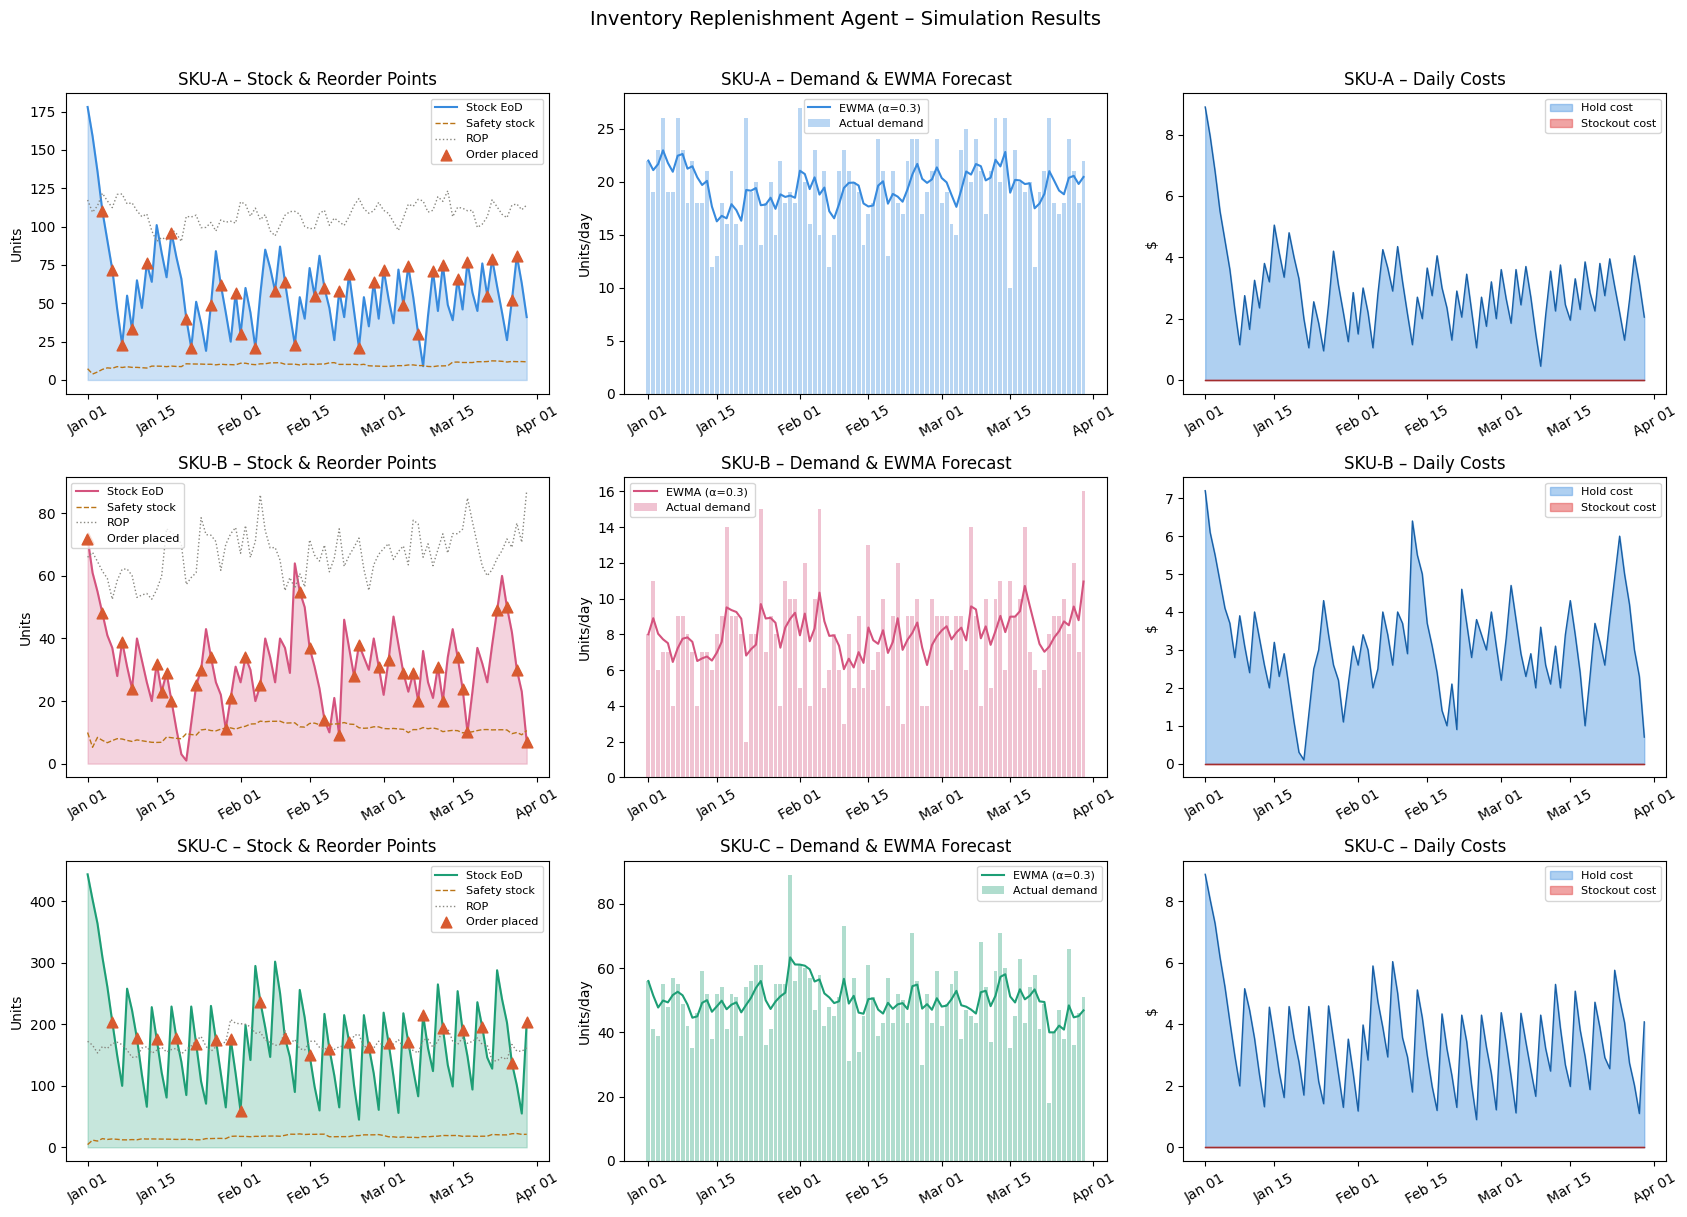

Chart saved to replenishment_results.png


In [17]:
# 9. ── Visualise results ───────────────────────────────────────────────────

fig, axes = plt.subplots(len(SKUS), 3, figsize=(17, 4 * len(SKUS)))
fig.suptitle("Inventory Replenishment Agent – Simulation Results", fontsize=14, y=1.01)

colors = {"SKU-A": "#378ADD", "SKU-B": "#D4537E", "SKU-C": "#1D9E75"}

for row, sku in enumerate(SKUS):
    d  = results["daily"][sku]
    c  = colors.get(sku, "steelblue")

    # ── Panel 1: Stock level & orders ──
    ax = axes[row, 0]
    ax.fill_between(d.index, d["stock_eod"], alpha=0.25, color=c)
    ax.plot(d.index, d["stock_eod"], color=c, lw=1.5, label="Stock EoD")
    ax.plot(d.index, d["ss"], color="#BA7517", lw=1, ls="--", label="Safety stock")
    ax.plot(d.index, d["rop"], color="#888780", lw=1, ls=":", label="ROP")
    order_days = d[d["order_qty"] > 0]
    ax.scatter(order_days.index, order_days["stock_eod"], marker="^",
               color="#D85A30", s=60, zorder=5, label="Order placed")
    ax.set_title(f"{sku} – Stock & Reorder Points")
    ax.set_ylabel("Units")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)

    # ── Panel 2: EWMA forecast vs actual ──
    ax = axes[row, 1]
    ax.bar(d.index, d["demand"], width=0.8, alpha=0.35, color=c, label="Actual demand")
    ax.plot(d.index, d["ewma"], color=c, lw=1.5, label=f"EWMA (α={alpha})")
    ax.set_title(f"{sku} – Demand & EWMA Forecast")
    ax.set_ylabel("Units/day")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)

    # ── Panel 3: Daily costs ──
    ax = axes[row, 2]
    ax.fill_between(d.index, d["hold_cost"], alpha=0.4, color="#378ADD", label="Hold cost")
    ax.fill_between(d.index, d["so_cost"], alpha=0.5, color="#E24B4A", label="Stockout cost")
    ax.plot(d.index, d["hold_cost"], color="#185FA5", lw=1)
    ax.plot(d.index, d["so_cost"], color="#A32D2D", lw=1)
    ax.set_title(f"{sku} – Daily Costs")
    ax.set_ylabel("$")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("replenishment_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to replenishment_results.png")


In [21]:
# 10. ── Sensitivity: vary alpha ────────────────────────────────────────────

print("\n=== Sensitivity: EWMA alpha vs total cost ===")
alpha_range = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
sens_rows = []
for a in alpha_range:
    r = run_claude_agent(demand, inventory_df, params, alpha=a)
    row = {"alpha": a}
    for sku in SKUS:
        row[f"{sku}_cost"] = r["summary"].loc[sku, "total_cost"]
        row[f"{sku}_fill"] = r["summary"].loc[sku, "fill_rate_%"]
    sens_rows.append(row)

sens_df = pd.DataFrame(sens_rows).set_index("alpha")
print(sens_df.round(2))

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for sku, c in colors.items():
    ax1.plot(sens_df.index, sens_df[f"{sku}_cost"], marker="o", label=sku, color=c)
    ax2.plot(sens_df.index, sens_df[f"{sku}_fill"], marker="o", label=sku, color=c)
ax1.set_title("Total cost vs EWMA alpha"); ax1.set_xlabel("alpha"); ax1.set_ylabel("$"); ax1.legend()
ax2.set_title("Fill rate % vs EWMA alpha"); ax2.set_xlabel("alpha"); ax2.set_ylabel("%"); ax2.legend()
plt.tight_layout()
plt.savefig("sensitivity_alpha.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sensitivity chart saved.")


=== Sensitivity: EWMA alpha vs total cost ===
CLAUDE-POWERED INVENTORY REPLENISHMENT AGENT

────────────────────────────────────────────────────────────────────────────────────────────────────
  DAY   1 | 2024-01-01
────────────────────────────────────────────────────────────────────────────────────────────────────
  SKU-A  demand=  22  ewma= 22.0  stock=   178  proj=    46  ss=  7.4  → WAIT         
         Claude: "Current inventory position of 178 units is well above the reorder point of 117.4 units, and projected inventory of 46 units at end of risk window exceeds the safety stock requirement of 7.4 units by a comfortable margin."
  SKU-B  demand=   8  ewma=  8.0  stock=    72  proj=     8  ss= 10.0  → WAIT         
         Claude: "Current inventory position of 72 units exceeds the reorder point of 66 units, and projected inventory of 8 units at end of risk window is below safety stock but ordering now would result in excess inventory given the high holding costs relative to cu

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_10552/2215133914.py", line 7, in <cell line: 0>
    r = run_claude_agent(demand, inventory_df, params, alpha=a)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10552/3332015189.py", line 141, in run_claude_agent
    decision = claude_replenishment_decision(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_10552/3332015189.py", line 49, in claude_replenishment_decision
    response = client.messages.create(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anthropic/_utils/_utils.py", line 283, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anthropic/resources/messages/messages.py", line 996, in create

TypeError: object of type 'NoneType' has no len()